### Duel output UNet on pennate diatoms - All the steps together
### Rayna Hamilton
### April 23, 2025

The below code combines code from asses_unet.ipynb, split_blobs.ipynb, and calculate_infection_ratios.ipynb to run the unet segmentation, cell separation and infection ratio calculation on all images in a folder.

In [1]:
# U-NET CNN Approach to Automated Image Analysis
    # base code from: https://www.kaggle.com/code/vbookshelf/simple-cell-segmentation-with-keras-and-u-net
#-------------------------------------------------------------------------------------------------------------

# Read in libraries
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
# %matplotlib inline

from skimage.io import imread, imshow
from skimage.transform import resize

import warnings
import cv2
import math
from math import sqrt

Indicate your desired input folder as well as output filenames here:

In [2]:
input_image_directory="../../data/sample_images/" 
output_mask_directory="../../sample_predictions/masks/"
output_coordinate_directory="../../sample_predictions/cell_coordinates/"
output_unique_mask_directory="../../sample_predictions/unique_masks/"
outlined_image_directory="../../sample_predictions/outlined_images/"
outlined_cell_directory="../../sample_predictions/outlined_cells/"
unique_cell_directory="../../sample_predictions/unique_cells/"
cell_infection_ratio_file="../../sample_predictions/infection_ratios_by_cell.csv"
image_infection_ratio_file="../../sample_predictions/infection_ratios_by_image.csv"

partially_infected_threshold,fully_infected_threshold=0.3,0.7
image_height,image_width=1040,1388
IMG_TILE_SIZE=400
IMG_CHANNELS = 3 # RGB
model_path='models/cell_model.h5'


In [3]:
for some_dir in [output_mask_directory,output_coordinate_directory,output_unique_mask_directory,outlined_image_directory,outlined_cell_directory,unique_cell_directory]:
    if not os.path.isdir(some_dir):
        os.mkdir(some_dir)

In [4]:
img_list = os.listdir(input_image_directory)
df_images = pd.DataFrame(img_list, columns=['image_id'])

Read in image data:

In [5]:
# Get lists of images and their masks.
image_id_list = list(df_images['image_id'])

X = np.zeros((len(image_id_list), image_height,image_width,3), dtype=np.uint8)

for i, image_id in enumerate(image_id_list):
    path_image = input_image_directory + image_id
    # read the image using skimage
    image = imread(path_image)
    X[i] = image
    
X.shape

(5, 1040, 1388, 3)

Split input image data into square tiles.  We do this step because the network is trained on 400x400 image tiles and only accepts this input shape.

In [6]:
def split_input_image(X):
    tiled_x_cell=[]
    max_x,max_y=image_height,image_width
    for i in range(len(X)):
        tiled_x_cell.append([])
        for y_pos in [0,400,800,1200]:
            for x_pos in [0,400,800]:
                image_slice=np.zeros((400,400,3), dtype=np.uint8)
                x_range=min(400,max_x-x_pos)
                y_range=min(400,max_y-y_pos)
                if x_range==400:
                    if y_range==400:
                        image_slice=X[i,x_pos:x_pos+400,y_pos:y_pos+400]
                    else:
                        image_slice=X[i,x_pos:x_pos+400,max_y-400:max_y]
                else:
                    if y_range==400:
                        image_slice=X[i,max_x-400:max_x,y_pos:y_pos+400]
                    else:
                        image_slice=X[i,max_x-400:max_x,max_y-400:max_y]
                tiled_x_cell[-1].append(image_slice)
    return tiled_x_cell

Define UNET architecture and read in trained weights:

In [7]:
from keras.models import Model, load_model
from keras.layers import Input
from keras.layers.core import Dropout, Lambda
from keras.layers.convolutional import Conv2D, Conv2DTranspose
from keras.layers.pooling import MaxPooling2D
from keras.layers import concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K

import tensorflow as tf

In [8]:

inputs = Input((IMG_TILE_SIZE,IMG_TILE_SIZE, IMG_CHANNELS))

s = Lambda(lambda x: x / 255) (inputs)

c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (s)
c1 = Dropout(0.1) (c1)
c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c1)
p1 = MaxPooling2D((2, 2)) (c1)

c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p1)
c2 = Dropout(0.1) (c2)
c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c2)
p2 = MaxPooling2D((2, 2)) (c2)

c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p2)
c3 = Dropout(0.2) (c3)
c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c3)
p3 = MaxPooling2D((2, 2)) (c3)

c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p3)
c4 = Dropout(0.2) (c4)
c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c4)
p4 = MaxPooling2D(pool_size=(2, 2)) (c4)

c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p4)
c5 = Dropout(0.3) (c5)
c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c5)

u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same') (c5)
u6 = concatenate([u6, c4])
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u6)
c6 = Dropout(0.2) (c6)
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c6)

u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same') (c6)
u7 = concatenate([u7, c3])
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u7)
c7 = Dropout(0.2) (c7)
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c7)

u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same') (c7)
u8 = concatenate([u8, c2])
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u8)
c8 = Dropout(0.1) (c8)
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c8)

u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same') (c8)
u9 = concatenate([u9, c1], axis=3)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u9)
c9 = Dropout(0.1) (c9)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c9)

outputs = Conv2D(1, (1, 1), activation='sigmoid') (c9)

model = Model(inputs=[inputs], outputs=[outputs])

model.compile(optimizer='adam', loss='binary_crossentropy',loss_weights=[1,1000])

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 400, 400, 3  0           []                               
                                )]                                                                
                                                                                                  
 lambda (Lambda)                (None, 400, 400, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 400, 400, 16  448         ['lambda[0][0]']                 
                                )                                                                 
                                                                                              

In [9]:
model.load_weights(model_path)

Predict input image tiles:

In [10]:
def join_prediction_tiles(prediction_tiles):
    #get predictions back into a single np array per image
    max_x,max_y=image_height,image_width
    single_prediction=np.zeros((image_height,image_width,1),dtype=np.float64)
    for i in range(len(prediction_tiles)):
        if i%3*IMG_TILE_SIZE+IMG_TILE_SIZE<max_x and int(i/3)*IMG_TILE_SIZE+IMG_TILE_SIZE<max_y:
            single_prediction[i%3*IMG_TILE_SIZE:i%3*IMG_TILE_SIZE+IMG_TILE_SIZE,int(i/3)*IMG_TILE_SIZE:int(i/3)*IMG_TILE_SIZE+IMG_TILE_SIZE,:]=prediction_tiles[i]
        elif i%3*IMG_TILE_SIZE+IMG_TILE_SIZE<max_x and int(i/3)*IMG_TILE_SIZE+IMG_TILE_SIZE>max_y:
            single_prediction[i%3*IMG_TILE_SIZE:i%3*IMG_TILE_SIZE+IMG_TILE_SIZE,int(i/3)*IMG_TILE_SIZE:max_y,:]=prediction_tiles[i][:,IMG_TILE_SIZE-(max_y-int(i/3)*IMG_TILE_SIZE):]
        elif i%3*IMG_TILE_SIZE+IMG_TILE_SIZE>max_x and int(i/3)*IMG_TILE_SIZE+IMG_TILE_SIZE<max_y:
            single_prediction[i%3*IMG_TILE_SIZE:max_x,int(i/3)*IMG_TILE_SIZE:int(i/3)*IMG_TILE_SIZE+IMG_TILE_SIZE,:]=prediction_tiles[i][IMG_TILE_SIZE-(max_x-i%3*IMG_TILE_SIZE):,:]
        else:
            single_prediction[i%3*IMG_TILE_SIZE:max_x,int(i/3)*IMG_TILE_SIZE:max_y,:]=prediction_tiles[i][IMG_TILE_SIZE-(max_x-i%3*IMG_TILE_SIZE):,IMG_TILE_SIZE-(max_y-int(i/3)*IMG_TILE_SIZE):,:]
    return (single_prediction>0.5)[:,:,0]

In [11]:
predictions=[]
tiled_x=split_input_image(X)
for i in range(len(tiled_x)):
    predictions.append(model.predict(np.array(tiled_x[i])))

1/1 [==============================] - 0s 363ms/step


Join tiled predictions back into a single image:

In [12]:
joined_predictions=[]
for j in range(len(X)):
    joined_predictions.append(join_prediction_tiles(predictions[j]))
predictions=joined_predictions

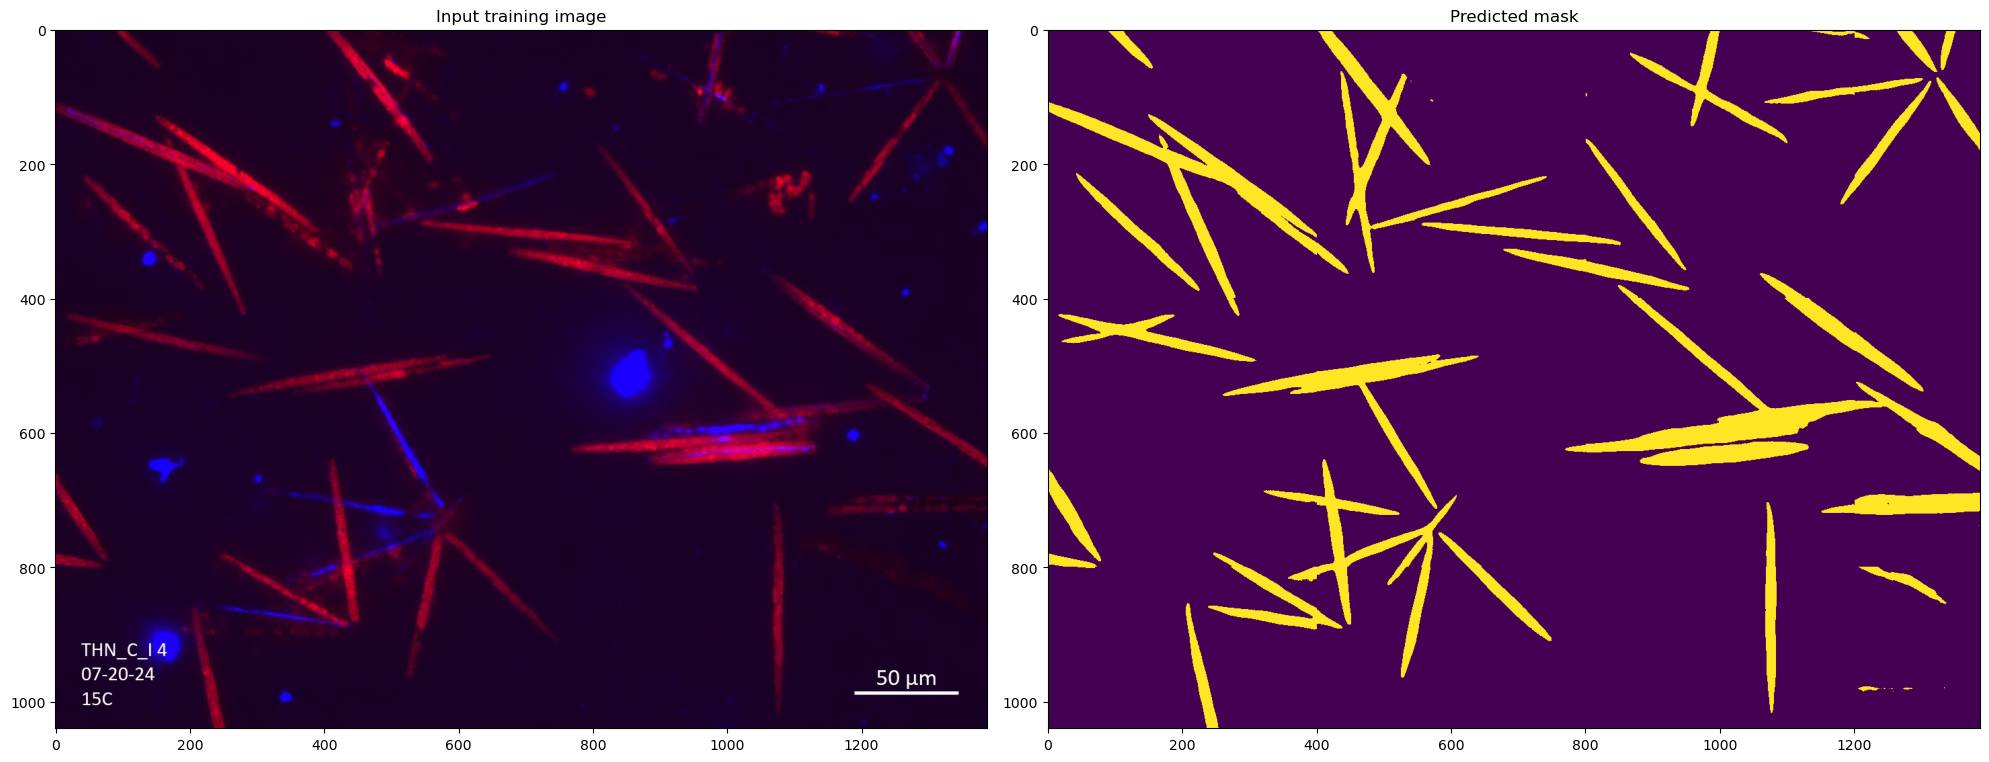

In [13]:
fig, ax = plt.subplots(1,2, figsize=(20, 8))
ax[0].imshow(X[-1])
ax[1].imshow(predictions[-1])
ax[0].set_title("Input training image")
ax[1].set_title("Predicted mask")
fig.tight_layout()

Remove predicted objects below a certain minimum pixel size (here 700).  We do this because we do not want to consider every distinct tiny clump of pixels as its own cell.

In [14]:
def remove_tiny_blobs(array,min_size=700):
    segmented_cells=np.zeros((image_height,image_width,3), dtype=np.uint8)
    clean_predictions=np.zeros((image_height,image_width), dtype=np.uint8)
    coordinates_to_blobs=dict()
    current_blob=-1
    clean_array=np.copy(array)
    blob_sizes=[]
    for i in range(0,len(array)):
        for j in range(0,len(array[i])):    
            if array[i,j]==1 and f"{i},{j}" not in coordinates_to_blobs.keys():
                red,green,blue=np.random.randint(50,255),np.random.randint(50,255),np.random.randint(50,255)
                #start a new blob
                current_blob+=1
                coordinates_to_check=[f"{i},{j}"]
                x,y=i,j
                while True:#expand outwards from current pixel position in all directions until no more filled coordinates are found
                    segmented_cells[x,y,0]=red
                    segmented_cells[x,y,1]=green
                    segmented_cells[x,y,2]=blue
                    coordinates_to_blobs[f"{x},{y}"]=current_blob
                    #check all four surrounding pixels
                    if x>0 and array[x-1,y]>0 and f"{x-1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x-1},{y}")
                    if x<len(array)-1 and array[x+1,y]>0 and f"{x+1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x+1},{y}")
                    if y>0 and array[x,y-1]>0 and f"{x},{y-1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y-1}")
                    if y<len(array[0])-1 and array[x,y+1]>0 and f"{x},{y+1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y+1}")
                    x=int(coordinates_to_check[-1].split(",")[0])
                    y=int(coordinates_to_check[-1].split(",")[1])
                    coordinates_to_check=coordinates_to_check[:-1]
                    if len(coordinates_to_check)==0:
                        blob_sizes.append(sum([val==current_blob for val in list(coordinates_to_blobs.values())]))
                        break
    for coordinate_pair,current_blob in coordinates_to_blobs.items():
        if blob_sizes[current_blob]>=min_size:
            x=int(coordinate_pair.split(",")[0])
            y=int(coordinate_pair.split(",")[1])
            clean_predictions[x,y]=1
    return coordinates_to_blobs,blob_sizes,clean_predictions


In [15]:
clean_predictions=[]
for i,prediction in enumerate(predictions):
    coordinates_to_blobs,blob_sizes,clean_predicted_image=remove_tiny_blobs(prediction) 
    clean_predictions.append(clean_predicted_image)
    cv2.imwrite(f"{output_mask_directory}/{df_images.at[i,'image_id']}",clean_predicted_image*255)

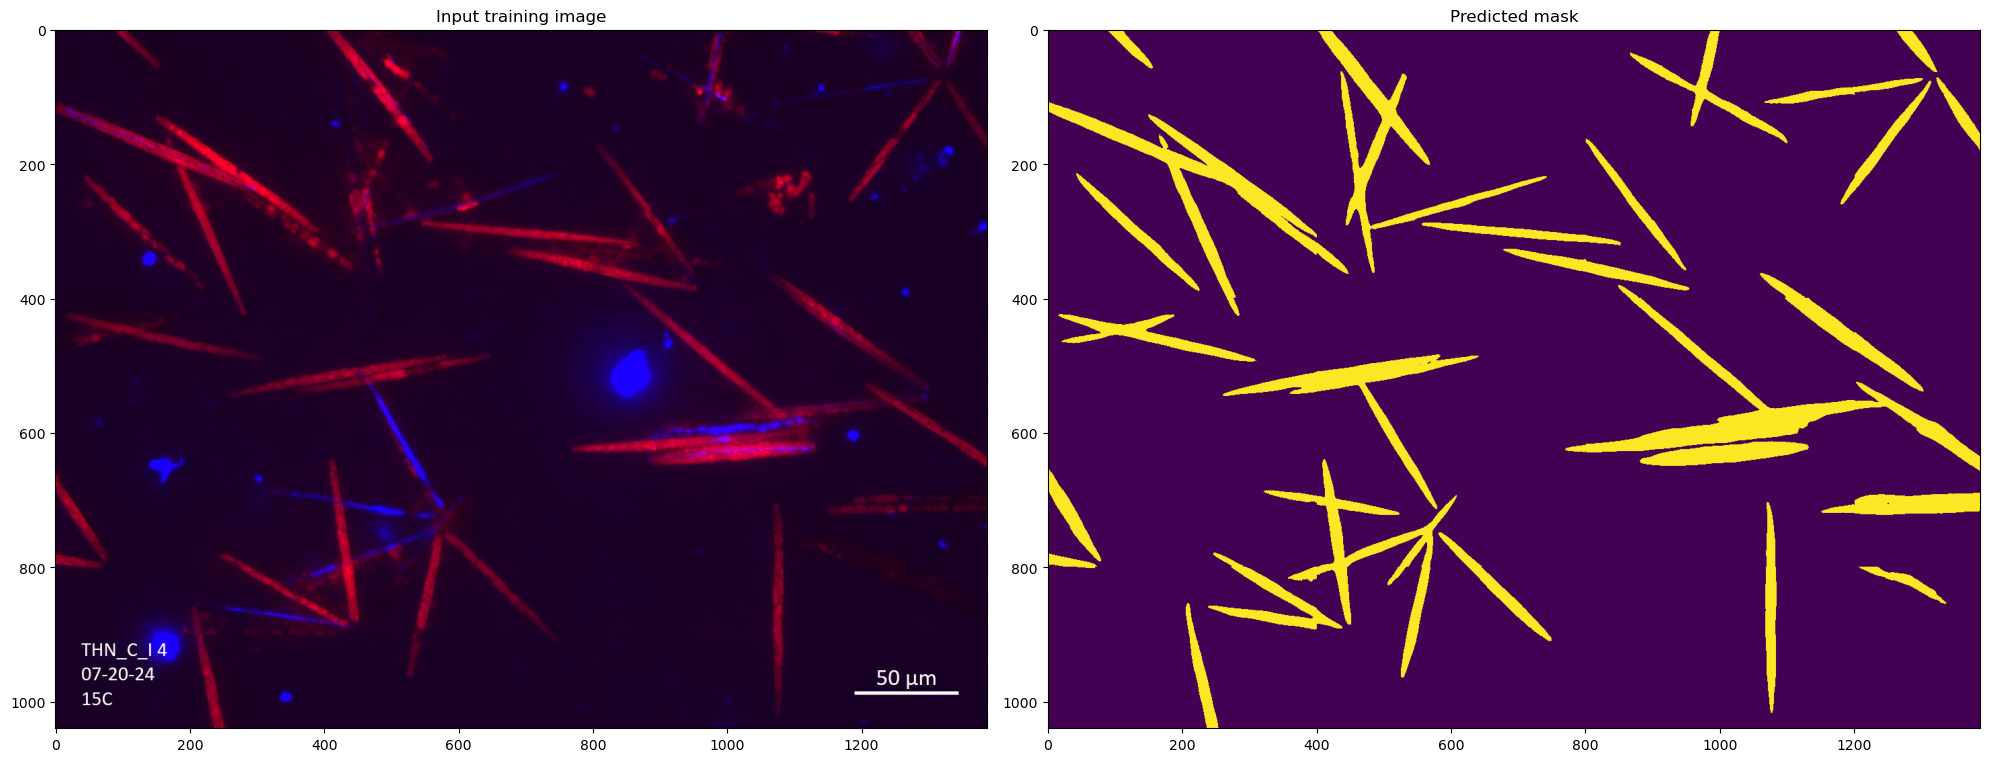

In [16]:
fig, ax = plt.subplots(1,2, figsize=(20, 8))
ax[0].imshow(X[-1])
ax[1].imshow(clean_predictions[-1])
ax[0].set_title("Input training image")
ax[1].set_title("Predicted mask")
fig.tight_layout()

In [17]:
predictions=clean_predictions

Split overlapping predictions into individual cells.  Briefly, this method attempts to find one or a few of the longest line within a given blob of pixels.  This involves trying pairs of coordinates found on the edges of a blob and slopes, checking if the corresponding line overlaps well with the current blob, then filtering down a set of acceptable lines to remove redundancy.  This is the slowest part of the pipeline by far and may require you to run multiple instances of the notebook on different input folders for sanity's sake.

In [18]:
def remove_overlapping_lines(lines,slope_threshold=0.2,distance_threshold=4):
    '''
    For an array of line coordinates, finds pairs of lines with start or end points within distance_threshold of each other and slopes within slope_threshold of each other, then removes the shorter line.
    '''
    line_slopes=[]
    for i,line in enumerate(lines):
        x11,y11,x12,y12=line
        if x11>x12:
                x11,y11,x12,y12=x12,y12,x11,y11
        lines[i]=x11,y11,x12,y12
        line_slopes.append((line[3]-line[1])/(line[2]-line[0])) 
    
    indices_to_remove=[]
    overlap_found=True
    while overlap_found:
        overlap_found=False
        for i,slope1 in enumerate(line_slopes):
            for j,slope2 in enumerate(line_slopes):
                if (i not in indices_to_remove and j not in indices_to_remove) and i<j:
                    if abs(slope2-slope1)<=slope_threshold: #examine pairs of lines with slopes within slope threshold
                        line1,line2=lines[i],lines[j]
                        x11,y11,x12,y12=line1 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 1
                        x21,y21,x22,y22=line2 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 2
                        if (sqrt((x11-x21)**2+(y11-y21)**2)<=distance_threshold) or (sqrt((x11-x22)**2+(y11-y22)**2)<=distance_threshold) or (sqrt((x12-x21)**2+(y12-y21)**2)<=distance_threshold) or (sqrt((x12-x22)**2+(y12-y22)**2)<=distance_threshold):
                            #Keep longer line:
                            overlap_found=True
                            if sqrt((x11-x12)**2 + (y11-y12)**2) > sqrt((x21-x22)**2 + (y21-y22)**2):
                                indices_to_remove.append(j)
                            else:
                                indices_to_remove.append(i)
    new_lines=[]
    for i,line in enumerate(lines):
        if i not in indices_to_remove:
            x1,y1,x2,y2=line
            new_lines.append(line)
    #print(f"Removed {len(set(indices_to_remove))} very similar lines.")
    return new_lines

def remove_intersecting_lines(lines,coordinates,slope_threshold=0.2,distance_threshold=4):
    '''
    For an array of line coordinates, repeatedly looks for lines with large numbers of overlapping pixels and removes the smaller line.
    '''
    indices_to_remove=[]
    overlap_found=True
    while overlap_found:
        overlap_found=False
        for i,line1 in enumerate(lines):
            for j,line2 in enumerate(lines):
                if (i not in indices_to_remove and j not in indices_to_remove) and i<j:
                    imagei,imagej=np.zeros((image_width,image_width)),np.zeros((image_width,image_width))
                    x11,y11,x12,y12=line1 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 1
                    x21,y21,x22,y22=line2 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 2
                    cv2.line(imagei,(x11,y11),(x12,y12),255,20)
                    i_coordinates=[]
                    for y,x in zip(*np.nonzero(imagei)):
                        if f"{x},{y}" in coordinates.keys():
                            i_coordinates.append(f"{x},{y}")
                    cv2.line(imagej,(x21,y21),(x22,y22),255,20)
                    j_coordinates=[]
                    for y,x in zip(*np.nonzero(imagej)):
                        if f"{x},{y}" in coordinates.keys():
                            j_coordinates.append(f"{x},{y}")
                    intersection=[val for val in i_coordinates if val in j_coordinates]
                    if len(i_coordinates)<200:
                        indices_to_remove.append(i)
                        #print(f"Removing {line1} due to insufficient size {len(i_coordinates)}.")
                        continue
                    if len(j_coordinates)<200:
                        indices_to_remove.append(j)
                        #print(f"Removing {line2} due to insufficient size {len(j_coordinates)}.")
                        continue
                        
                    if len(intersection)/len(i_coordinates)>0.4 or len(intersection)/len(j_coordinates)>0.4:
                        overlap_found=True
                        if sqrt((x11-x12)**2 + (y11-y12)**2) > sqrt((x21-x22)**2 + (y21-y22)**2):
                            indices_to_remove.append(j)
                            #print(f"Removing {line2} due to {line1}")
                        else:
                            indices_to_remove.append(i)
                            #print(f"Removing {line1} due to {line2}")

    new_lines=[]
    for i,line in enumerate(lines):
        if i not in indices_to_remove:
            x1,y1,x2,y2=line
            new_lines.append(line)
    #print(f"Removed {len(set(indices_to_remove))} very similar lines.")
    return new_lines

def get_pixels_from_line(line):
    '''
    Returns all pixels spanned by a line with specified start and end points.
    '''
    imagei=np.zeros((image_width,image_width))
    x1,y1,x2,y2=line
    cv2.line(imagei,(x1,y1),(x2,y2),255,20) 
    i_coordinates=dict()
    max_x,max_y=0,0
    for y,x in zip(*np.nonzero(imagei)):
        i_coordinates[f"{x},{y}"]=""
        if x>max_x:
            max_x=x
        if y>max_y:
            max_y=y
    return i_coordinates

def get_overlap_proportion(line,coordinates):
    '''
    Determines the proportion of a segmentation mask that is covered by a given line.
    '''
    imagei=np.zeros((image_height,image_width))
    x1,y1,x2,y2=line
    cv2.line(imagei,(x1,y1),(x2,y2),255,20)
    #if abs(slope2-slope1)<=slope_threshold: 
    i_coordinates=[]
    for y,x in zip(*np.nonzero(imagei)):
        if f"{x},{y}" in coordinates.keys():
            i_coordinates.append(f"{x},{y}")
    return len(i_coordinates)/len(coordinates)

def get_distance(coordinates1,coordinates2):
    '''
    Returns the distance between two coordinates in 2d space.
    '''
    x1,y1,x2,y2=int(coordinates1.split(",")[0]),int(coordinates1.split(",")[1]),int(coordinates2.split(",")[0]),int(coordinates2.split(",")[1])
    return math.sqrt(((y2-y1)**2)+((x2-x1)**2))

def check_line_fill(coordinates,x1,y1,x2,y2):
    '''
    Similar to get_overlap_proportion, but models lines as single pixel width.  This is a bit faster and thus used to round down the initial large set
    '''
    if x1>x2:
        x1,y1,x2,y2=x2,y2,x1,y1
    slope=(y2-y1)/(x2-x1)
    current_x,current_y=x1,y1
    total_steps,matching_steps=0,0
    while current_x<=x2:
        
        if f"{int(current_x)},{int(current_y)}" in coordinates.keys():
            matching_steps+=1
        total_steps+=1
        current_x,current_y=current_x+1,current_y+slope
    return matching_steps/total_steps
    
def get_blobs(array):
    '''
    From assess_unet.ipynb - Finds all non-overlapping objects (blobs) within a segmentation mask, and returns an image with each blob as a different colour.
    '''
    segmented_cells=np.zeros((image_height,image_width,3), dtype=np.uint8)
    coordinates_to_blobs=dict()
    current_blob=-1
    clean_array=np.copy(array)
    blob_sizes=[]
    for i in range(0,len(array)):
        for j in range(0,len(array[i])):    
            if array[i,j]==1 and f"{i},{j}" not in coordinates_to_blobs.keys():
                red,green,blue=np.random.randint(50,255),np.random.randint(50,255),np.random.randint(50,255)
                #start a new blob
                current_blob+=1
                coordinates_to_check=[f"{i},{j}"]
                x,y=i,j
                while True:#expand outwards from current pixel position in all directions until no more filled coordinates are found
                    segmented_cells[x,y,0]=red
                    segmented_cells[x,y,1]=green
                    segmented_cells[x,y,2]=blue
                    coordinates_to_blobs[f"{x},{y}"]=current_blob
                    #check all four surrounding pixels
                    if x>0 and array[x-1,y]>0 and f"{x-1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x-1},{y}")
                    if x<len(array)-1 and array[x+1,y]>0 and f"{x+1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x+1},{y}")
                    if y>0 and array[x,y-1]>0 and f"{x},{y-1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y-1}")
                    if y<len(array[0])-1 and array[x,y+1]>0 and f"{x},{y+1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y+1}")
                    x=int(coordinates_to_check[-1].split(",")[0])
                    y=int(coordinates_to_check[-1].split(",")[1])
                    coordinates_to_check=coordinates_to_check[:-1]
                    if len(coordinates_to_check)==0:
                        blob_sizes.append(sum([val==current_blob for val in list(coordinates_to_blobs.values())]))
                        break
    return coordinates_to_blobs,blob_sizes,segmented_cells
    
def separate_single_from_multi_cell(image,coordinates_to_blobs,min_line_length=150,min_overlap_proportion=0.8,pixel_step_size=5):
    '''
    For each distinct blob (pixels touching each other) in a segmentation, tries to find the single longest line within a blob by combining pairs of start and end coordinates from the edges of the blob.
    If the longest line has substantial pixel overlap with the blob, assume that this is a single-cell blob and return the blob unaltered.
    Otherwise, assume that the blob is multi-cell and:
        - Find all possible lines within a blob passing an overlap and line length threshold
        - Filter down this line list using remove_overlapping_lines and remove_intersecting_lines
        - Separate the blob regions based on whether they intersect with each of the final non-redundant lines, and remove all regions spanned by multiple lines
    '''
    coordinates_to_keep=dict()
    annotated_image=np.copy(image)
    single_cell_image=np.zeros(image.shape)
    blobs_to_keep=list(set(coordinates_to_blobs.values()))
    
    cell_number=0
    for blob in blobs_to_keep:
        coordinates={coordinate:"" for coordinate,blob1 in coordinates_to_blobs.items() if blob1==blob}
        longest_line_coordinates=["",""]
        longest_line=-1
        coordinates_to_check=dict()

        #get just candidate coordinates on the edges of the blob to reduce redundant computations
        for coordinate in coordinates.keys():
            x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
            if f"{x-1},{y}" not in coordinates.keys() or f"{x+1},{y}" not in coordinates.keys() or f"{x},{y-1}" not in coordinates.keys()  or f"{x},{y+1}" not in coordinates.keys():
                coordinates_to_check[coordinate]=""
                
        for coordinate1 in coordinates_to_check.keys():
            for coordinate2 in coordinates_to_check.keys():
                if coordinate1!=coordinate2:
                    line_length=get_distance(coordinate1,coordinate2)
                    if line_length>=min_line_length and line_length>longest_line:
                        
                        longest_line=line_length
                        longest_line_coordinates=[coordinate1,coordinate2]
        #print()
        coordinates1,coordinates2=longest_line_coordinates[0],longest_line_coordinates[1]
        if coordinates1=="":
            for coordinate in coordinates:
                coordinates_to_keep[coordinate]=cell_number
            cell_number+=1
            continue
        x1,y1,x2,y2=int(coordinates1.split(",")[0]),int(coordinates1.split(",")[1]),int(coordinates2.split(",")[0]),int(coordinates2.split(",")[1])
        
        #print(longest_line)
        #print(longest_line_coordinates)
        #overlap_proportion=check_line_fill(coordinates,x1,y1,x2,y2)
        overlap_proportion=get_overlap_proportion([x1,y1,x2,y2],coordinates)
        #print(overlap_proportion)
        
        if overlap_proportion>=min_overlap_proportion:
            cv2.line(annotated_image,(y1,x1),(y2,x2),(255,255,255),20)
            for coordinate in coordinates.keys():
                x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
                single_cell_image[x,y]=1
                coordinates_to_keep[coordinate]=cell_number
            cell_number+=1
        else:#likely a multicell blob, so find all lines then remove redundant lines
            #print("Likely multi-cell blob")
            
            some_lines=get_best_lines(coordinates_to_check,coordinates)
            #print(some_lines)   
            #print(len(some_lines))
            all_lines=remove_overlapping_lines(some_lines,slope_threshold=0.5,distance_threshold=30)
            #print(all_lines)
            unique_lines=remove_intersecting_lines(all_lines,coordinates,slope_threshold=0.5,distance_threshold=1000)
            #print(unique_lines)
            blacklist_coordinates=dict()
            coordinates_to_lines=dict()
            for k,line1 in enumerate(unique_lines):
                line1_coordinates=get_pixels_from_line(line1)
                for coordinate in line1_coordinates:
                    coordinates_to_lines[coordinate]=k+cell_number
                for line2 in unique_lines:
                    if line1!=line2:
                        line2_coordinates=get_pixels_from_line(line2)
                        for coordinate in line1_coordinates.keys():
                            if coordinate in line2_coordinates.keys():
                                blacklist_coordinates[coordinate]=""
            for coordinate in coordinates:
                if coordinate in coordinates_to_lines.keys() and coordinate not in blacklist_coordinates.keys():
                    coordinates_to_keep[coordinate]=coordinates_to_lines[coordinate]
            for line in unique_lines:
                x1,y1,x2,y2=line
                cv2.line(annotated_image,(y1,x1),(y2,x2),(255,255,255),20)
            #print(len(unique_lines))
            #print(unique_lines)
            cell_number=cell_number+len(unique_lines)
    #print(cell_number)        
    return annotated_image,single_cell_image,coordinates_to_keep

In [19]:
def get_best_lines(coordinates_to_check,coordinates):
    current_coordinate=list(coordinates_to_check.keys())[0]
    current_slope=1
    current_best_slope=current_slope
    line_lengths=dict()
    
    
    slopes_to_check=[slope/10 for slope in range(-100,100)]
    line_lengths=dict()
    for current_coordinate in coordinates_to_check.keys():
        best_line,best_line_length=-1,-1
        for slope in slopes_to_check:
            current_slope=slope
            current_x,current_y=int(current_coordinate.split(",")[0]),int(current_coordinate.split(",")[1])
            while f"{current_x},{int(current_y)}" in coordinates:
                current_x,current_y=current_x+1,current_y+current_slope
            current_x,current_y=current_x-1,current_y-current_slope
            line_length=get_distance(current_coordinate,f"{int(current_x)},{int(current_y)}")
            if line_length>best_line_length:
                best_line_length=line_length
                best_line=f"{current_x},{int(current_y)}"
            #current_slope=current_slope-0.1
        #print(current_coordinate,best_line,best_line_length)
        if best_line_length>100:
            line_lengths[f"{current_coordinate},{best_line}"]=best_line_length
    #print(len(line_lengths))
    #print(line_lengths)
    lines_to_return=[]
    for coordinates in line_lengths.keys():
        x1,y1,x2,y2=coordinates.split(",")
        lines_to_return.append([int(x1),int(y1),int(x2),int(y2)])
    return lines_to_return

In [20]:
coordinates_to_blobs,blob_sizes,blob_visualization=get_blobs(predictions[-1])    
annotated_image,single_cell_image,coordinates_to_keep=separate_single_from_multi_cell(predictions[-1],coordinates_to_blobs,min_line_length=100,min_overlap_proportion=0.95,pixel_step_size=5)

In [21]:
def plot_blobs(coordinates):
    '''
    From coordinates of unique cells returned by separate_single_from_multi_cell, plot the segmentation with each cell as its own color.
    '''
    to_plot=np.zeros((image_height,image_width,3), dtype=np.uint8)
    colours=dict()
    for cell_number in set(coordinates.values()):
        colours[cell_number]=[np.random.randint(50,255),np.random.randint(50,255),np.random.randint(50,255)]
    for coordinate,cell_number in coordinates.items():
        x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
        red,green,blue=colours[cell_number][0],colours[cell_number][1],colours[cell_number][2]
        to_plot[x,y,0]=red
        to_plot[x,y,1]=green
        to_plot[x,y,2]=blue
    return to_plot

In [22]:
unique_cell_image=plot_blobs(coordinates_to_keep)

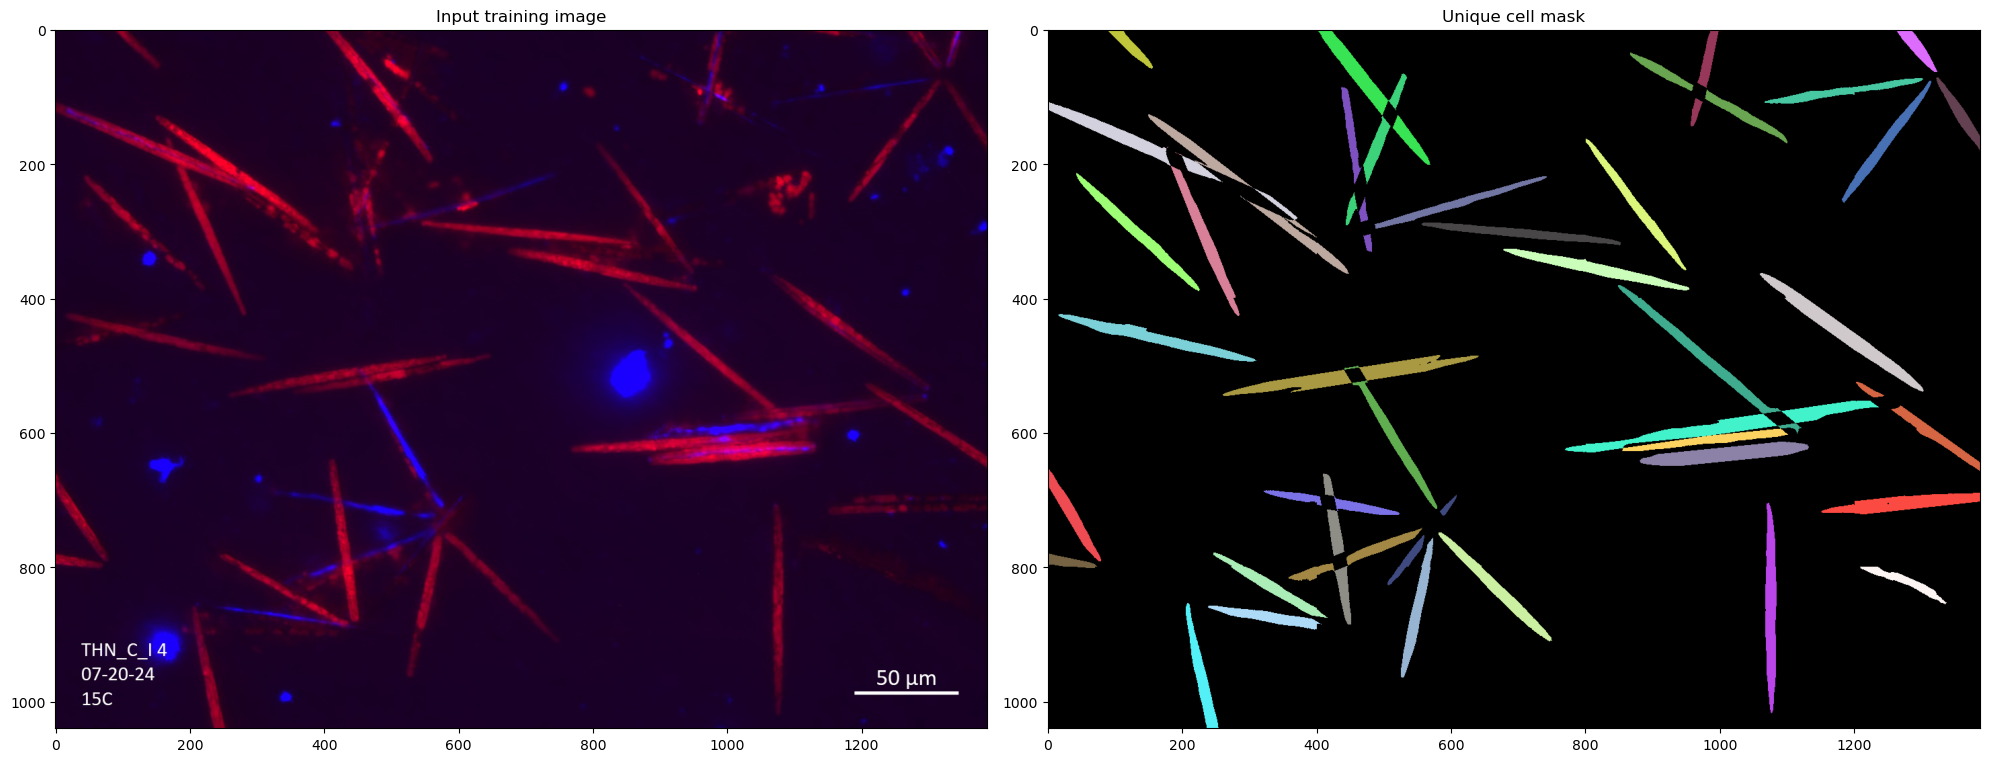

In [23]:
fig, ax = plt.subplots(1,2, figsize=(20, 8))
ax[0].imshow(X[-1])
ax[1].imshow(unique_cell_image)
ax[0].set_title("Input training image")
ax[1].set_title("Unique cell mask")
fig.tight_layout()

Above, each coloured blob corresponds to a unique cell, and overlap regions are removed as it is difficult to reliably determine which cell they belong to.  We will output images with each cell as its own colour and tsvs containing the coordinates of each cell.

In [24]:
for file in os.listdir(output_mask_directory):
    if file.endswith(".jpg"):
        if not os.path.exists(f"{output_coordinate_directory}/{file.replace('.jpg','.tsv')}"):
            mask=imread(f"{output_mask_directory}/{file}")
            mask=mask/255
            coordinates_to_blobs,blob_sizes,blob_visualization=get_blobs(mask)    
            annotated_image,single_cell_image,coordinates_to_keep=separate_single_from_multi_cell(mask,coordinates_to_blobs,min_line_length=100,min_overlap_proportion=0.95)
            unique_cell_image=plot_blobs(coordinates_to_keep)
            cv2.imwrite(f"{output_unique_mask_directory}/{file}",unique_cell_image)
            output=open(f"{output_coordinate_directory}/{file.replace('.jpg','.tsv')}","w")
            output.write("cell_number\tcell_coordinates\n")
            for cell_number in set(coordinates_to_keep.values()):
                output.write(str(cell_number)+"\t")
                for coordinates in coordinates_to_keep.keys():
                    if coordinates_to_keep[coordinates]==cell_number:
                        output.write(coordinates+";")
                output.write("\n")
            output.close()
            print(f"Done with {file}.")

Done with THN_B_I_15_5-20240726-C26.jpg.
Done with THN_C_I_15_4-20240720-C45.jpg.


I have also decided to output the sliced images containing each unique cell (with other cells blacked out) as this is the input data used by the infection ratio calculation.

In [25]:
#Read in coordinates of predicted cells as determined in split_blobs.ipynb
images,coordinates=dict(),dict()
for image_name in list(df_images.image_id):
    images[image_name]=imread(f"{input_image_directory}/{image_name}")
    coordinates[image_name]=dict()
    for line in open(f"{output_coordinate_directory}/{image_name.replace('.jpg','.tsv')}"):
        if not line.startswith('cell_number'):
            cell_number,cell_coordinates=line.strip().split("\t")
            coordinates[image_name][cell_number]=dict()
            for coordinate_pair in cell_coordinates.split(';'):
                if "," in coordinate_pair:
                    coordinates[image_name][cell_number][coordinate_pair]=""

In [26]:
min_x_range,min_y_range=50,50

outlined_images=dict()
for image in images:
    outlined_images[image]=np.copy(images[image])
    all_cell_coordinates=dict()
    for cell_number, cell_coordinates in coordinates[image].items():
        for coordinate_pair in cell_coordinates.keys():
                all_cell_coordinates[coordinate_pair]=""
    if not os.path.exists(f"{outlined_image_directory}/{image}"):
        for cell_number, cell_coordinates in coordinates[image].items():
            
            min_x,min_y,max_x,max_y=10000,10000,-1,-1
            for coordinate_pair in cell_coordinates.keys():
                x,y=int(coordinate_pair.split(",")[0]),int(coordinate_pair.split(",")[1])
                if x<min_x:
                    min_x=x
                if x>max_x:
                    max_x=x
                if y<min_y:
                    min_y=y
                if y>max_y:
                    max_y=y
            labelled=False
            for x in range(min_x,max_x):
                for y in range(min_y,max_y):
                    if f"{x},{y}" not in all_cell_coordinates.keys():
                        if f"{x-1},{y}" in cell_coordinates.keys() or f"{x+1},{y}" in cell_coordinates.keys() or f"{x},{y-1}" in cell_coordinates.keys()  or f"{x},{y+1}" in cell_coordinates.keys():
                            outlined_images[image][x,y]=255
                    if not labelled and f"{x},{y}" in cell_coordinates.keys():
                        labelled=True
                        cv2.putText(outlined_images[image],str(cell_number),(min(max(y,10),1340),min(max(x,20),1050)),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),3)
        cv2.imwrite(f"{outlined_image_directory}/{image}",cv2.cvtColor(outlined_images[image], cv2.COLOR_RGB2BGR))    
    print(f"Done with {image}.")

Done with AS_A_I_15_4-20240720-C28.jpg.
Done with AS_A_I_22_4-20240718-C15.jpg.
Done with AS_A_I_22_5-20240718-C13.jpg.
Done with THN_B_I_15_5-20240726-C26.jpg.
Done with THN_C_I_15_4-20240720-C45.jpg.


In [27]:
min_x_range,min_y_range=300,300
outlined_images=dict()
for image in images:
    outlined_images[image]=np.copy(images[image])
    all_cell_coordinates=dict()
    for cell_number, cell_coordinates in coordinates[image].items():
        for coordinate_pair in cell_coordinates.keys():
                all_cell_coordinates[coordinate_pair]=""
    for cell_number, cell_coordinates in coordinates[image].items():
       
        min_x,min_y,max_x,max_y=10000,10000,-1,-1
        for coordinate_pair in cell_coordinates.keys():
            x,y=int(coordinate_pair.split(",")[0]),int(coordinate_pair.split(",")[1])
            if x<min_x:
                min_x=x
            if x>max_x:
                max_x=x
            if y<min_y:
                min_y=y
            if y>max_y:
                max_y=y
        if (max_x-min_x)<min_x_range:
            shift=int((min_x_range-max_x+min_x)/2)
            min_x=max(min_x-shift,0)
            max_x=min(max_x+shift,image_height)
        if (max_y-min_y)<min_y_range:
            shift=int((min_y_range-max_y+min_y)/2)
            min_y=max(0,min_y-shift)
            max_y=min(max_y+shift,image_width)
        if not os.path.exists(f"{outlined_cell_directory}/{image.replace('.jpg','_cell_'+str(cell_number)+'_'+str(min_x)+','+str(min_y)+'.jpg')}"):
            subsetted_image=np.copy(images[image][min_x:max_x,min_y:max_y])
            outlined_subsetted_image=np.copy(images[image][min_x:max_x,min_y:max_y])
            for x in range(min_x,max_x):
                for y in range(min_y,max_y):
                    if f"{x},{y}" not in all_cell_coordinates.keys():
                        if f"{x-1},{y}" in cell_coordinates.keys() or f"{x+1},{y}" in cell_coordinates.keys() or f"{x},{y-1}" in cell_coordinates.keys()  or f"{x},{y+1}" in cell_coordinates.keys():
                            outlined_subsetted_image[x-min_x,y-min_y]=255
                    else:
                        if f"{x},{y}" not in cell_coordinates.keys():
                            subsetted_image[x-min_x,y-min_y]=0
            cv2.imwrite(f"{outlined_cell_directory}/{image.replace('.jpg','_cell_'+str(cell_number)+'_'+str(min_x)+','+str(min_y)+'.jpg')}",cv2.cvtColor(outlined_subsetted_image, cv2.COLOR_RGB2BGR))
            cv2.imwrite(f"{unique_cell_directory}/{image.replace('.jpg','_cell_'+str(cell_number)+'_'+str(min_x)+','+str(min_y)+'.jpg')}",cv2.cvtColor(subsetted_image, cv2.COLOR_RGB2BGR))
    print(f"Done with {image}.")

Done with AS_A_I_15_4-20240720-C28.jpg.
Done with AS_A_I_22_4-20240718-C15.jpg.
Done with AS_A_I_22_5-20240718-C13.jpg.
Done with THN_B_I_15_5-20240726-C26.jpg.
Done with THN_C_I_15_4-20240720-C45.jpg.


Calculate infection ratios:

In [28]:
infection_ratios=dict()
for file in os.listdir(unique_cell_directory):
    key="_".join(file.split("_")[:-3])+".jpg"
    cell_number=file.split("_")[-2]
    x_shift,y_shift=int(file.split("_")[-1].split(",")[0]),int(file.split("_")[-1].split(",")[1].replace(".jpg",""))
    image=imread(f"{unique_cell_directory}/{file}")
    cell_coordinates=coordinates[key][cell_number]
    red_pixels,blue_pixels,background_red_pixels,background_blue_pixels=[],[],[],[]
    for x in range(len(image)):
        for y in range(len(image[0])):
            red,blue=image[x,y,0],image[x,y,2]
            if f"{x+x_shift},{y+y_shift}" in cell_coordinates.keys():
                blue_pixels.append(blue)
                red_pixels.append(red)
            else:
                background_blue_pixels.append(blue)
                background_red_pixels.append(red)
    mean_background_blue,mean_background_red=np.mean(background_blue_pixels),np.mean(background_red_pixels)
    blue_pixels=np.float64(blue_pixels)
    red_pixels=np.float64(red_pixels)
    blue_pixels=blue_pixels-mean_background_blue
    red_pixels=red_pixels-mean_background_red
    blue_pixels[blue_pixels<0]=0
    red_pixels[red_pixels<0]=0
    infection_ratios[file]=sum(blue_pixels)/(sum(blue_pixels)+sum(red_pixels))

In [29]:
infection_ratios_by_image=dict()
output=open(cell_infection_ratio_file,"w")
output.write("image,cell_number,infection_ratio\n")
for cell,ratio in infection_ratios.items():
    image_key=("_".join(cell.split("_")[:-3]))+".jpg"
    if image_key not in infection_ratios_by_image:
        infection_ratios_by_image[image_key]=[]
    infection_ratios_by_image[image_key].append(ratio)
    output.write(f"{image_key},{cell.split('_')[-2]},{ratio}\n")
output.close()

In [30]:
df_images.index=list(df_images.image_id)
df_images["mean_infection_ratio"]=0.0
df_images["uninfected_cells"]=0
df_images["partially_infected_cells"]=0
df_images["late_infected_cells"]=0

In [31]:
for key,ratios in infection_ratios_by_image.items():
    df_images.at[key,"mean_infection_ratio"]=np.mean(ratios)
    for ratio in ratios:
        if ratio>=partially_infected_threshold:
            if ratio>=fully_infected_threshold:
                df_images.at[key,"late_infected_cells"]+=1
            else:
                df_images.at[key,"partially_infected_cells"]+=1
        else:
            df_images.at[key,"uninfected_cells"]+=1

In [32]:
df_images

,image_id,mean_infection_ratio,uninfected_cells,partially_infected_cells,late_infected_cells
AS_A_I_15_4-20240720-C28.jpg,AS_A_I_15_4-20240720-C28.jpg,0.622630,7,8,14
AS_A_I_22_4-20240718-C15.jpg,AS_A_I_22_4-20240718-C15.jpg,0.181220,12,2,1
AS_A_I_22_5-20240718-C13.jpg,AS_A_I_22_5-20240718-C13.jpg,0.214941,10,3,1
THN_B_I_15_5-20240726-C26.jpg,THN_B_I_15_5-20240726-C26.jpg,0.599922,5,11,10
THN_C_I_15_4-20240720-C45.jpg,THN_C_I_15_4-20240720-C45.jpg,0.212028,31,5,5


In [33]:
df_images[["mean_infection_ratio","uninfected_cells","partially_infected_cells","late_infected_cells"]].to_csv(image_infection_ratio_file)